# Labeling

- Optuna: TPC-only threshold optimization
- K-means: TPC-only threshold clustering
- Both methods fit exclusively on training data; the derived threshold is then applied to test and validation sets

---

**Methodological rationale**

Class labels (Early / Intermediate / Late) reflect the biological freshness state of each sample.
Changing the train/test split does not alter the microbiological condition of a given sample.

Optuna and K-means were each fit independently on the training data of all 10 seeds, yielding the following threshold stability:

| Method | thr_low std | thr_high std | seed-42 Δ from mean |
|---|---|---|---|
| Optuna  | 0.0561 | 0.0522 | low: 0.0335 / high: 0.0257 |
| K-means | 0.0407 | 0.0386 | low: 0.0205 / high: 0.0153 |

Inter-seed threshold variability was ≤ 0.06 log CFU/g, and the seed-42 estimate deviated less than 0.04 from the 10-seed mean, confirming its suitability as a representative value.
This fixed threshold was applied uniformly to all 270 samples to ensure biologically consistent label assignment.

The validity of fixing seed-42 was further confirmed during model training through a sensitivity analysis spanning all 10 label_seed × 10 train_seed combinations.

> Kaufman et al. (2012). Leakage in data mining. *ACM TKDD*, 6(4). doi:10.1145/2382577.2382579
> Cawley & Talbot (2010). On over-fitting in model selection. *JMLR*, 11, 2079–2107.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import optuna
from optuna.samplers import TPESampler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
optuna.logging.set_verbosity(optuna.logging.WARNING)

CODE_DIR = "/home/admin-01/taeho/BRL_chicken/revision/code"
PKL_DIR  = os.path.join(CODE_DIR, "data", "pkl")
output_dir = CODE_DIR   # labeling figures → code/ 루트 저장

with open(os.path.join(PKL_DIR, 'splits.pkl'), 'rb') as f:
    splits_data = pickle.load(f)

splits       = splits_data['splits']
seeds        = splits_data['seeds']
feature_cols = splits_data['feature_cols']
tpc_col      = splits_data['tpc_col']

def extract_day(description):
    m = re.match(r'A(\d+)-\d+', str(description))
    return int(m.group(1)) if m else np.nan

print(f"seeds: {seeds}")
print(f"features: {len(feature_cols)}개")
s = splits[seeds[0]]
print(f"seed={seeds[0]} | train: {len(s['train'])} / test: {len(s['test'])} / val: {len(s['val'])}")


seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
features: 110개
seed=38 | train: 189 / test: 54 / val: 27


## 2. Labeling Functions (TPC-only)

### `label_by_tpc`
Assigns one of three class labels based on TPC value: Early (0) / Late (1) / Intermediate (2)

### `evaluate_labeling` — Proportion-based objective function

Evaluated on the seed-42 training set (n ≈ 189). All constraints are defined as within-training proportions, making them independent of absolute sample size.

| Constraint | Criterion | Expression |
|---|---|---|
| Early proportion at Day 0 | ≥ **50%** of Day 0 samples labeled Early | `n_fresh_0 / n_day0 ≥ 0.50` |
| Late proportion at Day 18 | ≥ **50%** of Day 18 samples labeled Late | `n_decay_18 / n_day18 ≥ 0.50` |
| **Intermediate proportion** | ≥ **30%** of total training samples labeled Intermediate | `n_middle / total ≥ 0.296` |
| Late proportion upper bound | ≤ **48%** of total training samples labeled Late | `n_decay / total ≤ 0.48` |
| Early proportion upper bound | ≤ **48%** of total training samples labeled Early | `n_fresh / total ≤ 0.48` |
| Day coverage | Each label must span ≥ **3 distinct storage days** | — |

In [ ]:
def label_by_tpc(df, tpc_thr_low, tpc_thr_high):
    """Early=0, Late=1, Intermediate=2"""
    cond_fresh = df[tpc_col] < tpc_thr_low
    cond_decay = df[tpc_col] >= tpc_thr_high
    return np.where(cond_fresh, 0, np.where(cond_decay, 1, 2))

# 비율 기준 임계값 (train 내 비율로 정의)
FRESH0_MIN_RATIO  = 0.50   # Day  0 중 Early        ≥ 50%
DECAY18_MIN_RATIO = 0.50   # Day 18 중 Late         ≥ 50%
MIDDLE_MIN_RATIO  = 0.30   # 전체 중 Intermediate  ≥ 30%

def evaluate_labeling(df, label_col='Label'):
    """비율 기반 목적함수 — train 크기에 무관하게 동작."""
    df = df.copy()
    df['Day'] = df['Description'].apply(extract_day).astype(int)
    day_list  = sorted(df['Day'].unique())
    day_stats = df.groupby('Day')[label_col].value_counts().unstack(fill_value=0)
    penalty   = 0

    total    = len(df)
    n_fresh  = (df[label_col] == 0).sum()
    n_decay  = (df[label_col] == 1).sum()
    n_middle = (df[label_col] == 2).sum()

    n_day0  = int(day_stats.loc[0].sum())  if 0  in day_stats.index else 0
    n_day18 = int(day_stats.loc[18].sum()) if 18 in day_stats.index else 0

    n_fresh_0  = int(day_stats.loc[0,  0] if (0 in day_stats.columns and 0  in day_stats.index) else 0)
    n_decay_18 = int(day_stats.loc[18, 1] if (1 in day_stats.columns and 18 in day_stats.index) else 0)

    # 1. Day 0 Early 비율 ≥ 50%
    if n_day0 > 0:
        r = n_fresh_0 / n_day0
        if r < FRESH0_MIN_RATIO:
            penalty += (FRESH0_MIN_RATIO - r) * n_day0 * 2

    # 2. Day 18 Late 비율 ≥ 50%
    if n_day18 > 0:
        r = n_decay_18 / n_day18
        if r < DECAY18_MIN_RATIO:
            penalty += (DECAY18_MIN_RATIO - r) * n_day18 * 2

    # 3. Intermediate 비율 ≥ 30%
    if total > 0:
        r = n_middle / total
        if r < MIDDLE_MIN_RATIO:
            penalty += (MIDDLE_MIN_RATIO - r) * total * 2

    # 4. Late 비율 ≤ 48%
    if total > 0 and n_decay / total > 0.48:
        penalty += (n_decay / total - 0.48) * 100

    # 5. Early 비율 ≤ 48%
    if total > 0 and n_fresh / total > 0.48:
        penalty += (n_fresh / total - 0.48) * 100

    # 6. 각 label ≥ 3일 이상 등장
    for label in [0, 1, 2]:
        days_with_label = (day_stats[label] > 0).sum() if label in day_stats.columns else 0
        if days_with_label < 3:
            penalty += (len(day_list) - days_with_label) * 2

    fresh_by_day = day_stats[0].reindex(day_list, fill_value=0) if 0 in day_stats.columns else pd.Series(0, index=day_list)
    decay_by_day = day_stats[1].reindex(day_list, fill_value=0) if 1 in day_stats.columns else pd.Series(0, index=day_list)
    fresh_diff = fresh_by_day.iloc[0] - fresh_by_day.iloc[-1]
    decay_diff = decay_by_day.iloc[-1] - decay_by_day.iloc[0]

    valid_count = (df[label_col] >= 0).sum()
    if valid_count < 50:
        return -1000, {
            'fresh_diff': fresh_diff, 'decay_diff': decay_diff, 'penalty': penalty,
            'n_fresh_0': n_fresh_0, 'n_decay_18': n_decay_18,
            'n_fresh': int(n_fresh), 'n_decay': int(n_decay), 'n_middle': int(n_middle),
            'valid_count': int(valid_count),
            'fresh_ratio':  n_fresh  / total if total > 0 else 0,
            'decay_ratio':  n_decay  / total if total > 0 else 0,
            'middle_ratio': n_middle / total if total > 0 else 0,
        }

    score = 5 * (fresh_diff + decay_diff) - penalty
    return score, {
        'fresh_diff': fresh_diff, 'decay_diff': decay_diff, 'penalty': penalty,
        'n_fresh_0': n_fresh_0, 'n_decay_18': n_decay_18,
        'n_fresh': int(n_fresh), 'n_decay': int(n_decay), 'n_middle': int(n_middle),
        'valid_count': int(valid_count),
        'fresh_ratio':  n_fresh  / total if total > 0 else 0,
        'decay_ratio':  n_decay  / total if total > 0 else 0,
        'middle_ratio': n_middle / total if total > 0 else 0,
    }

## 3. Optuna Threshold Fitting — All 10 Seeds

- Optuna fitting run independently on each seed's training data (n ≈ 189, 500 trials per seed)
- Threshold distributions compared across 10 seeds to verify the representativeness of seed-42
- The seed-42 threshold was fixed and applied uniformly to the train / test / validation splits of all 10 seeds

In [3]:
LABEL_SEED      = 42
optuna_thr_log  = {}

for label_seed in seeds:
    train_df = pd.DataFrame(splits[label_seed]['train']).copy()
    tpc_min  = train_df[tpc_col].min()
    tpc_max  = train_df[tpc_col].max()

    def _objective(trial):
        lo = trial.suggest_float('tpc_thr_low',  tpc_min, tpc_max - 0.5)
        hi = trial.suggest_float('tpc_thr_high', lo + 0.5, tpc_max)
        df_ = train_df.copy()
        df_['Label'] = label_by_tpc(df_, lo, hi)
        score, stats = evaluate_labeling(df_, label_col='Label')
        trial.set_user_attr('stats', stats)
        return score

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=label_seed))
    study.optimize(_objective, n_trials=500, show_progress_bar=False)

    bp    = study.best_params
    stats = study.best_trial.user_attrs['stats']
    optuna_thr_log[label_seed] = {
        'tpc_thr_low':  bp['tpc_thr_low'],
        'tpc_thr_high': bp['tpc_thr_high'],
        'best_score':   study.best_value,
        'n_fresh':      stats['n_fresh'],
        'n_middle':     stats['n_middle'],
        'n_decay':      stats['n_decay'],
    }
    if label_seed == LABEL_SEED:
        optuna_study = study   # 수렴 그래프 / parameter space 시각화용

    print(f"seed={label_seed}  low={bp['tpc_thr_low']:.4f}  high={bp['tpc_thr_high']:.4f}  "
          f"score={study.best_value:.2f}  E={stats['n_fresh']} I={stats['n_middle']} L={stats['n_decay']}")

# seed-42 대표값 추출
optuna_thr_low  = optuna_thr_log[LABEL_SEED]['tpc_thr_low']
optuna_thr_high = optuna_thr_log[LABEL_SEED]['tpc_thr_high']

# ── Threshold 안정성 요약 ──────────────────────────────────────────
lows  = [optuna_thr_log[s]['tpc_thr_low']  for s in seeds]
highs = [optuna_thr_log[s]['tpc_thr_high'] for s in seeds]
print(f"\n=== Optuna threshold stability (10 seeds) ===")
print(f"  thr_low  : mean={np.mean(lows):.4f}  std={np.std(lows):.4f}  range=[{min(lows):.4f}, {max(lows):.4f}]")
print(f"  thr_high : mean={np.mean(highs):.4f}  std={np.std(highs):.4f}  range=[{min(highs):.4f}, {max(highs):.4f}]")
print(f"\nseed-42 vs mean:")
print(f"  thr_low  {optuna_thr_low:.4f} vs {np.mean(lows):.4f}  (Δ={abs(optuna_thr_low-np.mean(lows)):.4f})")
print(f"  thr_high {optuna_thr_high:.4f} vs {np.mean(highs):.4f}  (Δ={abs(optuna_thr_high-np.mean(highs)):.4f})")
print(f"\n→ seed-42 threshold를 대표값으로 선택, 전체 seeds에 공통 적용")

seed=38  low=4.2407  high=6.3515  score=191.04  E=105 I=56 L=28
seed=39  low=4.2035  high=6.2741  score=197.21  E=96 I=60 L=33
seed=40  low=4.2289  high=6.3514  score=188.50  E=103 I=58 L=28
seed=41  low=4.3568  high=6.4225  score=183.93  E=109 I=56 L=24
seed=42  low=4.2214  high=6.3727  score=180.62  E=99 I=62 L=28
seed=43  low=4.2428  high=6.3654  score=226.68  E=97 I=62 L=30
seed=44  low=4.2401  high=6.2563  score=168.50  E=103 I=57 L=29
seed=45  low=4.3700  high=6.4237  score=180.33  E=109 I=57 L=23
seed=46  low=4.2035  high=6.3169  score=179.03  E=102 I=60 L=27
seed=47  low=4.2412  high=6.3355  score=184.03  E=102 I=58 L=29

=== Optuna threshold stability (10 seeds) ===
  thr_low  : mean=4.2549  std=0.0561  range=[4.2035, 4.3700]
  thr_high : mean=6.3470  std=0.0522  range=[6.2563, 6.4237]

seed-42 vs mean:
  thr_low  4.2214 vs 4.2549  (Δ=0.0335)
  thr_high 6.3727 vs 6.3470  (Δ=0.0257)

→ seed-42 threshold를 대표값으로 선택, 전체 seeds에 공통 적용


## 4. Optuna Convergence History

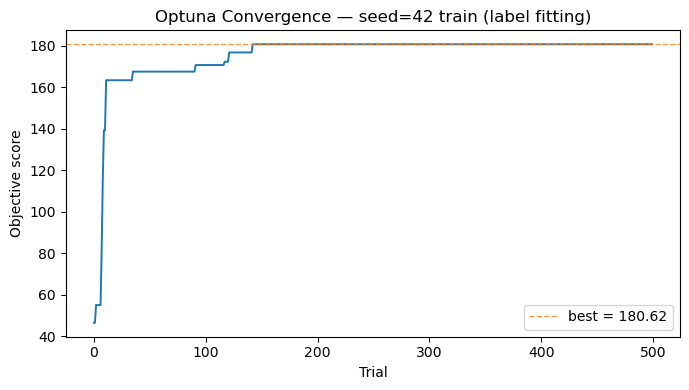

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_optuna_convergence_seed42.png


In [4]:
CONV_COLOR = '#1f77b4'

trials      = optuna_study.trials
best_so_far = []
best_val    = -np.inf
for t in trials:
    if t.value is not None and t.value > best_val:
        best_val = t.value
    best_so_far.append(best_val)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(best_so_far)), best_so_far, color=CONV_COLOR, linewidth=1.4)
ax.axhline(best_so_far[-1], color='#ff7f0e', linestyle='--', linewidth=1.0, alpha=0.8,
           label=f'best = {best_so_far[-1]:.2f}')
ax.set_title(f'Optuna Convergence — seed={LABEL_SEED} train (label fitting)')
ax.set_xlabel('Trial')
ax.set_ylabel('Objective score')
ax.legend()
fig.tight_layout()
save_path = os.path.join(output_dir, f'fig_optuna_convergence_seed{LABEL_SEED}.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## 5. K-means Threshold Fitting — 10 seeds

In [5]:
kmeans_threshold_log = {}

for label_seed in seeds:
    train_df = pd.DataFrame(splits[label_seed]['train']).copy()
    train_df['Day'] = train_df['Description'].apply(extract_day)

    X_km        = train_df[['Day', tpc_col]].values
    scaler_km_s = StandardScaler()
    X_km_scaled = scaler_km_s.fit_transform(X_km)

    km_s = KMeans(n_clusters=3, random_state=label_seed, n_init=20)
    km_s.fit(X_km_scaled)

    centers_orig = scaler_km_s.inverse_transform(km_s.cluster_centers_)
    cdf = pd.DataFrame(centers_orig, columns=['Day_center', 'TPC_center'])
    cdf['raw_cluster_id'] = range(3)
    cdf = cdf.sort_values('TPC_center').reset_index(drop=True)
    tpc_c = cdf['TPC_center'].values

    lo = (tpc_c[0] + tpc_c[1]) / 2
    hi = (tpc_c[1] + tpc_c[2]) / 2

    kmeans_threshold_log[label_seed] = {
        'tpc_thr_low':  lo,
        'tpc_thr_high': hi,
        'centers':      list(tpc_c),
    }

    # seed-42 시각화용 변수 보존 (원본 Cell 11 호환)
    if label_seed == LABEL_SEED:
        scaler_km             = scaler_km_s
        km                    = km_s
        centers_df            = cdf.copy()
        tpc_centers           = tpc_c.copy()
        tpc_sorted_to_final   = {0: 0, 1: 2, 2: 1}
        raw_to_final          = {int(cdf.loc[rank, 'raw_cluster_id']): tpc_sorted_to_final[rank]
                                  for rank in range(3)}
        labels_km             = np.array([raw_to_final[c] for c in km_s.predict(X_km_scaled)])
        train_42_km           = train_df.copy()
        train_42_km['KMeans_Label'] = labels_km

    print(f"seed={label_seed}  low={lo:.4f}  high={hi:.4f}  "
          f"centers={[round(float(c), 4) for c in tpc_c]}")

kmeans_thr_low  = float(kmeans_threshold_log[LABEL_SEED]['tpc_thr_low'])
kmeans_thr_high = float(kmeans_threshold_log[LABEL_SEED]['tpc_thr_high'])

# ── Threshold 안정성 요약 ──────────────────────────────────────────
km_lows  = [float(kmeans_threshold_log[s]['tpc_thr_low'])  for s in seeds]
km_highs = [float(kmeans_threshold_log[s]['tpc_thr_high']) for s in seeds]
print(f"\n=== K-means threshold stability (10 seeds) ===")
print(f"  thr_low  : mean={np.mean(km_lows):.4f}  std={np.std(km_lows):.4f}  range=[{min(km_lows):.4f}, {max(km_lows):.4f}]")
print(f"  thr_high : mean={np.mean(km_highs):.4f}  std={np.std(km_highs):.4f}  range=[{min(km_highs):.4f}, {max(km_highs):.4f}]")
print(f"\nseed-42 vs mean:")
print(f"  thr_low  {kmeans_thr_low:.4f} vs {np.mean(km_lows):.4f}  (Δ={abs(kmeans_thr_low-np.mean(km_lows)):.4f})")
print(f"  thr_high {kmeans_thr_high:.4f} vs {np.mean(km_highs):.4f}  (Δ={abs(kmeans_thr_high-np.mean(km_highs)):.4f})")
print(f"\n→ seed-42 threshold를 대표값으로 선택, 전체 seeds에 공통 적용")

seed=38  low=3.8362  high=5.2321  centers=[3.5898, 4.0827, 6.3815]
seed=39  low=3.8801  high=5.2567  centers=[3.6405, 4.1198, 6.3936]
seed=40  low=3.8829  high=5.3077  centers=[3.5856, 4.1802, 6.4351]
seed=41  low=3.8070  high=5.2266  centers=[3.5483, 4.0657, 6.3876]
seed=42  low=3.8643  high=5.2693  centers=[3.6137, 4.115, 6.4235]
seed=43  low=3.9016  high=5.2948  centers=[3.6024, 4.2008, 6.3888]
seed=44  low=3.8795  high=5.2648  centers=[3.595, 4.1639, 6.3656]
seed=45  low=3.9151  high=5.3196  centers=[3.5972, 4.233, 6.4062]
seed=46  low=3.9518  high=5.3407  centers=[3.6016, 4.3021, 6.3793]
seed=47  low=3.9294  high=5.3333  centers=[3.634, 4.2249, 6.4417]

=== K-means threshold stability (10 seeds) ===
  thr_low  : mean=3.8848  std=0.0407  range=[3.8070, 3.9518]
  thr_high : mean=5.2845  std=0.0386  range=[5.2266, 5.3407]

seed-42 vs mean:
  thr_low  3.8643 vs 3.8848  (Δ=0.0205)
  thr_high 5.2693 vs 5.2845  (Δ=0.0153)

→ seed-42 threshold를 대표값으로 선택, 전체 seeds에 공통 적용


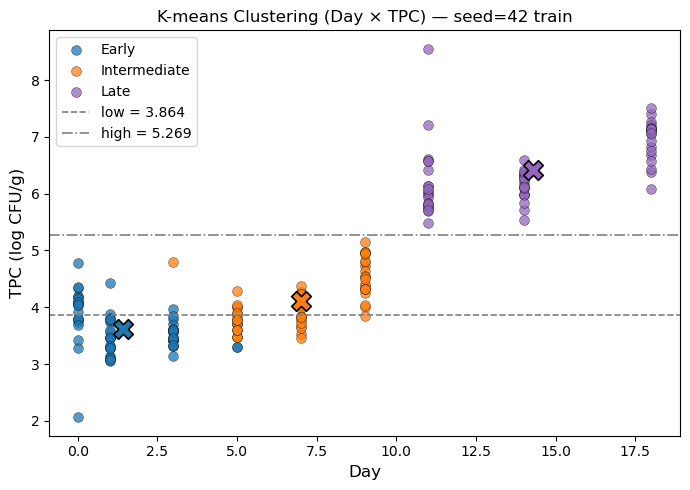

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_kmeans_scatter_seed42.png


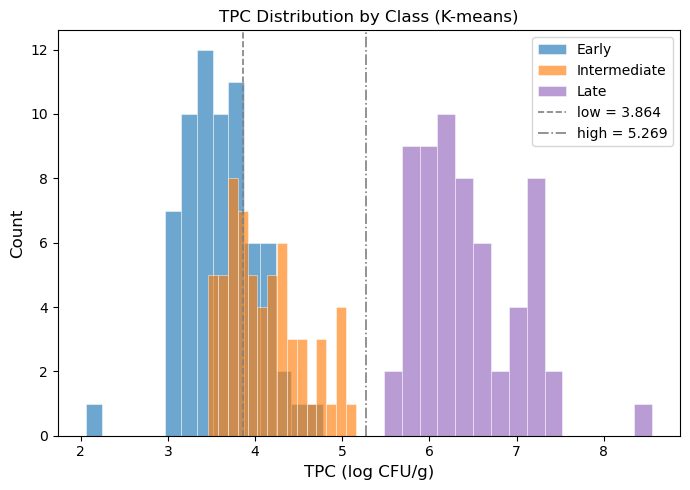

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_kmeans_tpc_hist_seed42.png


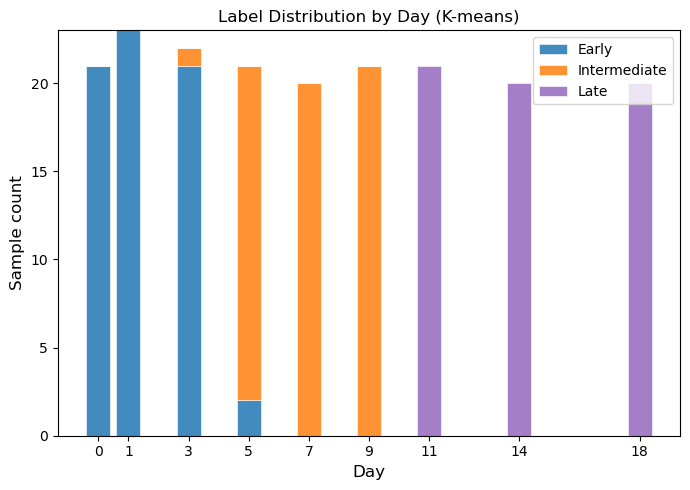

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_kmeans_day_dist_seed42.png


In [6]:
C_EARLY  = '#1f77b4'
C_INTER  = '#ff7f0e'
C_LATE   = '#9467bd'

KM_COLORS      = {0: C_EARLY, 2: C_INTER, 1: C_LATE}
KM_LABEL_NAMES = {0: 'Early', 2: 'Intermediate', 1: 'Late'}

# ── Fig 1: Day × TPC scatter ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for lbl in [0, 2, 1]:
    mask = train_42_km['KMeans_Label'] == lbl
    ax.scatter(train_42_km.loc[mask, 'Day'],
               train_42_km.loc[mask, tpc_col],
               color=KM_COLORS[lbl], label=KM_LABEL_NAMES[lbl],
               alpha=0.75, s=50, edgecolors='k', linewidths=0.3)
for rank in range(3):
    lbl = tpc_sorted_to_final[rank]
    ax.scatter(centers_df.loc[rank, 'Day_center'],
               centers_df.loc[rank, 'TPC_center'],
               color=KM_COLORS[lbl], s=200, marker='X',
               edgecolors='k', linewidths=1.2, zorder=5)
ax.axhline(kmeans_thr_low,  color='gray', linestyle='--', linewidth=1.2,
           label=f'low = {kmeans_thr_low:.3f}')
ax.axhline(kmeans_thr_high, color='gray', linestyle='-.', linewidth=1.2,
           label=f'high = {kmeans_thr_high:.3f}')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('TPC (log CFU/g)', fontsize=12)
ax.set_title(f'K-means Clustering (Day × TPC) — seed={LABEL_SEED} train', fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
p = os.path.join(CODE_DIR, f'fig_kmeans_scatter_seed{LABEL_SEED}.png')
fig.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p}")

# ── Fig 2: TPC 분포 histogram ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for lbl in [0, 2, 1]:
    mask = train_42_km['KMeans_Label'] == lbl
    ax.hist(train_42_km.loc[mask, tpc_col], bins=15,
            color=KM_COLORS[lbl], label=KM_LABEL_NAMES[lbl],
            alpha=0.65, edgecolor='white', linewidth=0.5)
ax.axvline(kmeans_thr_low,  color='gray', linestyle='--', linewidth=1.2,
           label=f'low = {kmeans_thr_low:.3f}')
ax.axvline(kmeans_thr_high, color='gray', linestyle='-.', linewidth=1.2,
           label=f'high = {kmeans_thr_high:.3f}')
ax.set_xlabel('TPC (log CFU/g)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('TPC Distribution by Class (K-means)', fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
p = os.path.join(CODE_DIR, f'fig_kmeans_tpc_hist_seed{LABEL_SEED}.png')
fig.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p}")

# ── Fig 3: Day별 stacked bar ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
day_label_cnt = (train_42_km.groupby(['Day', 'KMeans_Label'])
                 .size().unstack(fill_value=0)
                 .reindex(columns=[0, 2, 1], fill_value=0))
days   = day_label_cnt.index
bottom = np.zeros(len(days))
for lbl in [0, 2, 1]:
    vals = day_label_cnt[lbl].values
    ax.bar(days, vals, bottom=bottom,
           color=KM_COLORS[lbl], label=KM_LABEL_NAMES[lbl],
           alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += vals
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Sample count', fontsize=12)
ax.set_title('Label Distribution by Day (K-means)', fontsize=12)
ax.set_xticks(days)
ax.legend(fontsize=10)
fig.tight_layout()
p = os.path.join(CODE_DIR, f'fig_kmeans_day_dist_seed{LABEL_SEED}.png')
fig.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {p}")

## 6. Final Labels — Fixed Threshold from Seed-42

Independent fitting across all 10 seeds showed that inter-seed threshold variability was ≤ 0.06 log CFU/g for both Optuna and K-means, confirming threshold stability.
Seed-42 was selected as the representative seed, as its threshold deviated less than 0.04 from the 10-seed mean.

| Method | seed-42 thr_low | seed-42 thr_high | 10-seed std (low / high) |
|---|---|---|---|
| Optuna  | 4.2214 | 6.3727 | 0.0561 / 0.0522 |
| K-means | 3.8643 | 5.2693 | 0.0407 / 0.0386 |

The seed-42 threshold was applied uniformly to the train / test / validation splits of all 10 seeds, ensuring that each sample receives an identical label regardless of the random seed used for data partitioning.

In [7]:
# Optuna fixed threshold → 모든 seed split에 적용
labeled_splits = {}
for seed in seeds:
    labeled_splits[seed] = {}
    for part in ['train', 'test', 'val']:
        df = splits[seed][part].copy()
        df['Label'] = label_by_tpc(df, optuna_thr_low, optuna_thr_high)
        labeled_splits[seed][part] = df

# K-means fixed threshold → 모든 seed split에 적용
kmeans_labeled_splits = {}
for seed in seeds:
    kmeans_labeled_splits[seed] = {}
    for part in ['train', 'test', 'val']:
        df = splits[seed][part].copy()
        df['Label'] = label_by_tpc(df, kmeans_thr_low, kmeans_thr_high)
        kmeans_labeled_splits[seed][part] = df

In [8]:
# labeled_splits (Optuna, seed-42 fixed threshold)
with open(os.path.join(PKL_DIR, 'labeled_splits.pkl'), 'wb') as f:
    pickle.dump({'labeled_splits': labeled_splits,
                 'seeds': seeds, 'feature_cols': feature_cols, 'tpc_col': tpc_col}, f)

# kmeans_labeled_splits (K-means, seed-42 fixed threshold)
with open(os.path.join(PKL_DIR, 'kmeans_labeled_splits.pkl'), 'wb') as f:
    pickle.dump({'labeled_splits': kmeans_labeled_splits,
                 'seeds': seeds, 'feature_cols': feature_cols, 'tpc_col': tpc_col}, f)

# 10-seed 전체 threshold log 저장 (supplementary 근거)
with open(os.path.join(PKL_DIR, 'threshold_log.pkl'), 'wb') as f:
    pickle.dump(optuna_thr_log, f)

with open(os.path.join(PKL_DIR, 'kmeans_threshold_log.pkl'), 'wb') as f:
    pickle.dump(kmeans_threshold_log, f)

# 최종 threshold 값 (seed-42 대표값)
with open(os.path.join(PKL_DIR, 'avg_thresholds.pkl'), 'wb') as f:
    pickle.dump({
        'optuna':  {'tpc_thr_low': optuna_thr_low,  'tpc_thr_high': optuna_thr_high},
        'kmeans':  {'tpc_thr_low': kmeans_thr_low,   'tpc_thr_high': kmeans_thr_high},
    }, f)

print("저장 완료 →", PKL_DIR)
print(f"  labeled_splits.pkl        Optuna  seed-42 threshold: low={optuna_thr_low:.4f}, high={optuna_thr_high:.4f}")
print(f"  kmeans_labeled_splits.pkl K-means seed-42 threshold: low={kmeans_thr_low:.4f},  high={kmeans_thr_high:.4f}")
print(f"  threshold_log.pkl         Optuna  10-seed 전체 결과")
print(f"  kmeans_threshold_log.pkl  K-means 10-seed 전체 결과")
print(f"  avg_thresholds.pkl        최종 대표 threshold")

저장 완료 → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl
  labeled_splits.pkl        Optuna  seed-42 threshold: low=4.2214, high=6.3727
  kmeans_labeled_splits.pkl K-means seed-42 threshold: low=3.8643,  high=5.2693
  threshold_log.pkl         Optuna  10-seed 전체 결과
  kmeans_threshold_log.pkl  K-means 10-seed 전체 결과
  avg_thresholds.pkl        최종 대표 threshold


In [9]:
def plot_tpc_hist_single(df, thr_low, thr_high, title='', save_path=None):
    """TPC 분포 히스토그램 + threshold 선 시각화."""
    C_EARLY  = '#1f77b4'
    C_INTER  = '#ff7f0e'
    C_LATE   = '#9467bd'

    df = df.copy()
    df['_Label'] = label_by_tpc(df, thr_low, thr_high)
    label_map = {0: ('Early', C_EARLY), 2: ('Intermediate', C_INTER), 1: ('Late', C_LATE)}

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for lbl in [0, 2, 1]:
        mask = df['_Label'] == lbl
        name, color = label_map[lbl]
        ax.hist(df.loc[mask, tpc_col], bins=20, color=color, alpha=0.65,
                label=f'{name} (n={mask.sum()})', edgecolor='white', linewidth=0.5)

    ax.axvline(thr_low,  color='gray', linestyle='--', linewidth=1.5,
               label=f'low  = {thr_low:.4f}')
    ax.axvline(thr_high, color='gray', linestyle='-.',  linewidth=1.5,
               label=f'high = {thr_high:.4f}')

    ax.set_xlabel('TPC (log CFU/g)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

## 7. Visualization — Seed-42 Fitting Basis

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_optuna_tpc_seed42.png


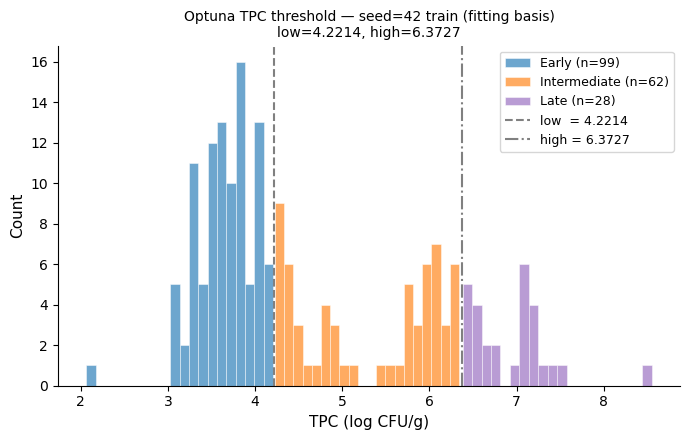

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_optuna_tpc_all270.png


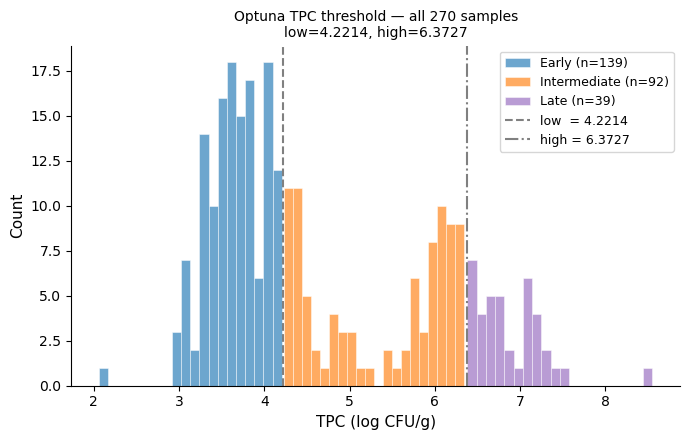

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_kmeans_tpc_seed42.png


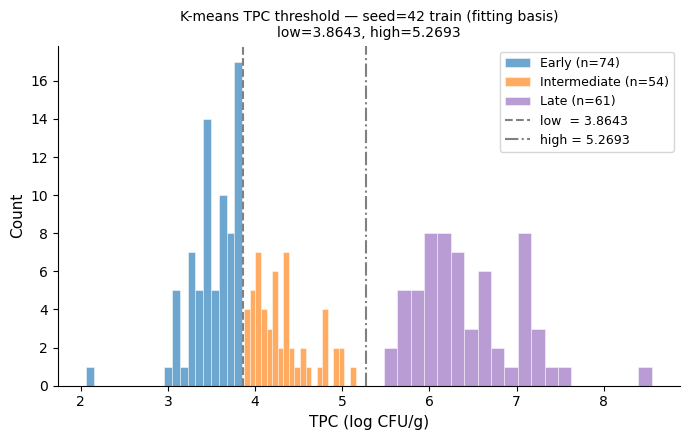

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/fig_kmeans_tpc_all270.png


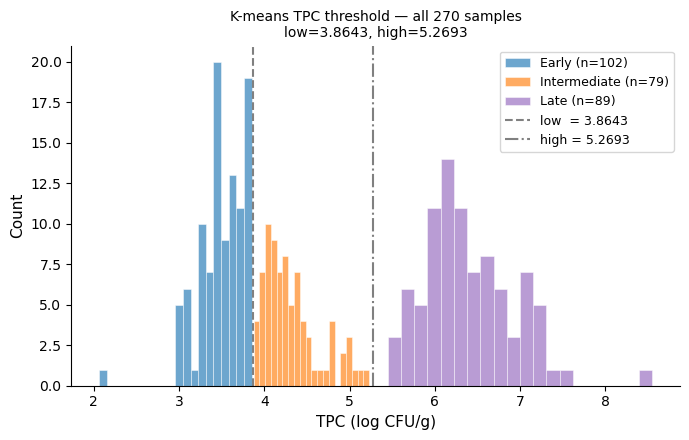

In [10]:
# ── Optuna ────────────────────────────────────────────────────────────
# seed 42 train (fitting 기준)
plot_tpc_hist_single(
    splits[LABEL_SEED]['train'],
    optuna_thr_low, optuna_thr_high,
    title=f'Optuna TPC threshold — seed={LABEL_SEED} train (fitting basis)\nlow={optuna_thr_low:.4f}, high={optuna_thr_high:.4f}',
    save_path=os.path.join(output_dir, f'fig_optuna_tpc_seed{LABEL_SEED}.png')
)

# 전체 270개 적용 결과
all_270 = pd.concat([splits[LABEL_SEED][p] for p in ['train', 'test', 'val']])
plot_tpc_hist_single(
    all_270,
    optuna_thr_low, optuna_thr_high,
    title=f'Optuna TPC threshold — all 270 samples\nlow={optuna_thr_low:.4f}, high={optuna_thr_high:.4f}',
    save_path=os.path.join(output_dir, 'fig_optuna_tpc_all270.png')
)

# ── K-means ───────────────────────────────────────────────────────────
# seed 42 train (fitting 기준)
plot_tpc_hist_single(
    splits[LABEL_SEED]['train'],
    kmeans_thr_low, kmeans_thr_high,
    title=f'K-means TPC threshold — seed={LABEL_SEED} train (fitting basis)\nlow={kmeans_thr_low:.4f}, high={kmeans_thr_high:.4f}',
    save_path=os.path.join(output_dir, f'fig_kmeans_tpc_seed{LABEL_SEED}.png')
)

# 전체 270개 적용 결과
plot_tpc_hist_single(
    all_270,
    kmeans_thr_low, kmeans_thr_high,
    title=f'K-means TPC threshold — all 270 samples\nlow={kmeans_thr_low:.4f}, high={kmeans_thr_high:.4f}',
    save_path=os.path.join(output_dir, 'fig_kmeans_tpc_all270.png')
)

## Optuna objective a K-means clustering parameter space figure 

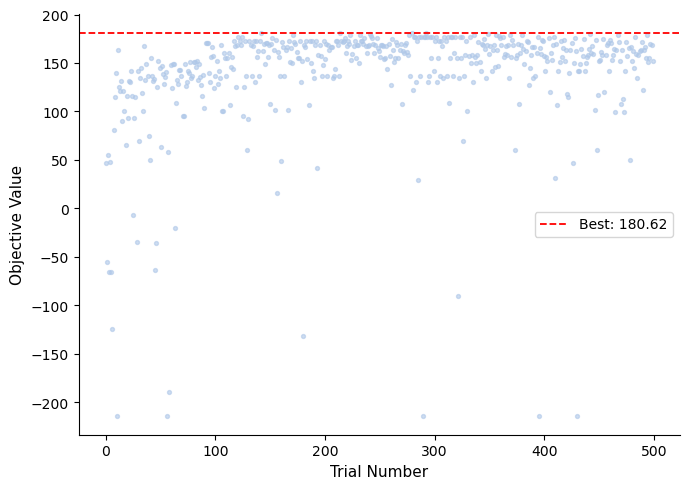

Saved: fig_optuna_history.png


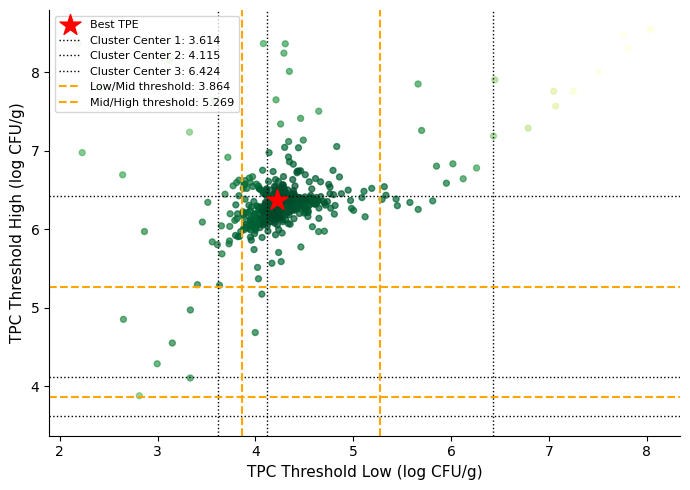

Saved: fig_kmeans_paramspace.png

Best: 180.62  |  low=4.2214, high=6.3727
KMeans centers: [np.float64(3.614), np.float64(4.115), np.float64(6.424)]
Thresholds: low=3.864, high=5.269


In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

trials_data = [
    (t.number, t.params['tpc_thr_low'], t.params['tpc_thr_high'], t.value)
    for t in optuna_study.trials
    if t.value is not None
]
trial_nums  = np.array([d[0] for d in trials_data])
trial_lows  = np.array([d[1] for d in trials_data])
trial_highs = np.array([d[2] for d in trials_data])
trial_vals  = np.array([d[3] for d in trials_data])

best_val    = optuna_study.best_value
best_params = optuna_study.best_params

# ── Left: Objective Value History ─────────────────────────────
fig1, ax = plt.subplots(figsize=(7, 5))
ax.scatter(trial_nums, trial_vals, s=8, color='#aec7e8', alpha=0.6, zorder=2)
ax.axhline(best_val, color='red', linestyle='--', linewidth=1.3,
           label=f'Best: {best_val:.2f}')
ax.set_xlabel('Trial Number', fontsize=11)
ax.set_ylabel('Objective Value', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
fig1.tight_layout()
fig1.savefig(os.path.join(output_dir, 'fig_optuna_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: fig_optuna_history.png")

# ── Right: KMeans Cluster Parameter Space ─────────────────────
fig2, ax = plt.subplots(figsize=(7, 5))
norm = mcolors.Normalize(vmin=trial_vals.min(), vmax=trial_vals.max())
cmap = plt.cm.YlGn

sc = ax.scatter(trial_lows, trial_highs,
                c=trial_vals, cmap=cmap, norm=norm,
                s=18, alpha=0.7, zorder=2)

ax.scatter(best_params['tpc_thr_low'], best_params['tpc_thr_high'],
           c='red', marker='*', s=250, zorder=5, label='Best TPE')

for i, c in enumerate(tpc_centers):
    ax.axvline(c, color='black', linestyle=':', linewidth=1.0,
               label=f'Cluster Center {i+1}: {c:.3f}')
    ax.axhline(c, color='black', linestyle=':', linewidth=1.0)

for thr, name in [(kmeans_thr_low,  f'Low/Mid threshold: {kmeans_thr_low:.3f}'),
                  (kmeans_thr_high, f'Mid/High threshold: {kmeans_thr_high:.3f}')]:
    ax.axvline(thr, color='orange', linestyle='--', linewidth=1.5, label=name)
    ax.axhline(thr, color='orange', linestyle='--', linewidth=1.5)

ax.set_xlabel('TPC Threshold Low (log CFU/g)', fontsize=11)
ax.set_ylabel('TPC Threshold High (log CFU/g)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
fig2.tight_layout()
fig2.savefig(os.path.join(output_dir, 'fig_kmeans_paramspace.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: fig_kmeans_paramspace.png")

print(f"\nBest: {best_val:.2f}  |  low={best_params['tpc_thr_low']:.4f}, high={best_params['tpc_thr_high']:.4f}")
print(f"KMeans centers: {[round(c, 3) for c in tpc_centers]}")
print(f"Thresholds: low={kmeans_thr_low:.3f}, high={kmeans_thr_high:.3f}")

## Supplementary Table S1 — Threshold Stability Statistical Test

### Method: Grubbs Outlier Test

**Rationale**

Each threshold column contains one value per seed (n = 10).
Conventional between-group comparisons (e.g., ANOVA, Tukey's HSD) are not applicable here,
as they require repeated measurements within groups to estimate within-group variance.

Instead, the **Grubbs test** (Grubbs, 1950) assesses whether the most extreme value
in a single sample of n observations constitutes a statistical outlier,
making it appropriate for evaluating whether all seeds were drawn from the same distribution.

**Procedure**

1. Applied independently to each threshold column (Optuna thr_low / thr_high, K-means thr_low / thr_high)
2. Grubbs statistic:
   $$G = \frac{\max |x_i - \bar{x}|}{s}$$
3. Critical value at α = 0.05, degrees of freedom n − 2:
   $$G_{\text{crit}} = \frac{n-1}{\sqrt{n}} \sqrt{\frac{t^2_{\alpha/(2n),\, n-2}}{n-2+t^2_{\alpha/(2n),\, n-2}}}$$
4. If G > G_crit, the corresponding seed is flagged as an outlier and removed; the test is then reapplied iteratively to the remaining values

**Results**

No statistically significant outlier was detected in any of the four threshold columns at α = 0.05.
This supports the conclusion that thresholds derived across the 10 seeds originate from a common distribution
and that no individual seed yields a value that is statistically discrepant from the rest.

In [12]:
import openpyxl
from openpyxl.styles import Font, Alignment, Border, Side
from scipy import stats

# ── 데이터 구성 ────────────────────────────────────────────────────
rows = []
for s in seeds:
    o = optuna_thr_log[s]
    k = kmeans_threshold_log[s]
    rows.append({
        'Seed':           s,
        'Optuna_low':     round(o['tpc_thr_low'],  4),
        'Optuna_high':    round(o['tpc_thr_high'], 4),
        'KMeans_low':     round(k['tpc_thr_low'],  4),
        'KMeans_high':    round(k['tpc_thr_high'], 4),
    })

df_thr = pd.DataFrame(rows)
thr_cols = ['Optuna_low', 'Optuna_high', 'KMeans_low', 'KMeans_high']

# ── Grubbs test (iterative, α=0.05) ───────────────────────────────
def grubbs_letters(values, alpha=0.05):
    """각 값에 letter annotation 반환 (outlier → 'b', 나머지 → 'a')"""
    data      = np.array(values, dtype=float)
    n         = len(data)
    outliers  = set()
    remaining = list(range(n))
    while len(remaining) > 3:
        sub   = data[remaining]
        mean  = np.mean(sub)
        std   = np.std(sub, ddof=1)
        if std == 0:
            break
        G_idx = int(np.argmax(np.abs(sub - mean)))
        G     = np.abs(sub[G_idx] - mean) / std
        m     = len(remaining)
        t_c   = stats.t.ppf(1 - alpha / (2 * m), df=m - 2)
        G_c   = ((m - 1) / np.sqrt(m)) * np.sqrt(t_c**2 / (m - 2 + t_c**2))
        if G > G_c:
            outliers.add(remaining[G_idx])
            remaining.pop(G_idx)
        else:
            break
    return ['b' if i in outliers else 'a' for i in range(n)]

# 열별 letter 계산
letters = {col: grubbs_letters(df_thr[col].values) for col in thr_cols}

# 결과 출력
print("=== Grubbs outlier test (α=0.05) ===")
for col in thr_cols:
    unique = set(letters[col])
    print(f"  {col:15s}: {'outlier detected → ' + str([seeds[i] for i,l in enumerate(letters[col]) if l=='b']) if len(unique)>1 else 'no outlier (all a)'}")

# ── 통계 행 ────────────────────────────────────────────────────────
mean_row  = {'Seed': 'Mean',      **{c: round(df_thr[c].mean(), 4)                               for c in thr_cols}}
std_row   = {'Seed': 'SD',        **{c: round(df_thr[c].std(ddof=0), 4)                           for c in thr_cols}}
cv_row    = {'Seed': 'CV (%)',    **{c: round(df_thr[c].std(ddof=0) / df_thr[c].mean() * 100, 2)  for c in thr_cols}}
s42       = df_thr[df_thr['Seed'] == LABEL_SEED].iloc[0]
delta_row = {'Seed': 'Δ seed-42', **{c: round(abs(s42[c] - df_thr[c].mean()), 4)                 for c in thr_cols}}

df_out = pd.concat([df_thr, pd.DataFrame([mean_row, std_row, cv_row, delta_row])], ignore_index=True)

# ── Excel 저장 ─────────────────────────────────────────────────────
xlsx_path = os.path.join(PKL_DIR.replace('/pkl', ''), 'suppl_table_thresholds.xlsx')

col_headers = {
    'Seed':        'Seed',
    'Optuna_low':  'Optuna\nthr_low',
    'Optuna_high': 'Optuna\nthr_high',
    'KMeans_low':  'K-means\nthr_low',
    'KMeans_high': 'K-means\nthr_high',
}

SUP    = {'a': 'ᵃ', 'b': 'ᵇ'}
bold_f = Font(bold=True)
ital_f = Font(italic=True)
center = Alignment(horizontal='center', vertical='center', wrap_text=True)
thin   = Side(style='thin')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Threshold Stability'

# 헤더
for col_i, label in enumerate(col_headers.values(), start=1):
    cell = ws.cell(row=1, column=col_i, value=label)
    cell.font = bold_f; cell.alignment = center; cell.border = border
ws.row_dimensions[1].height = 30

# 데이터 행
for row_i, row_data in enumerate(df_out.itertuples(index=False), start=2):
    seed_val  = row_data.Seed
    is_seed42 = str(seed_val) == str(LABEL_SEED)
    is_stat   = str(seed_val) in ('Mean', 'SD', 'CV (%)', 'Δ seed-42')
    seed_idx  = seeds.index(seed_val) if seed_val in seeds else None

    for col_i, key in enumerate(col_headers.keys(), start=1):
        raw = getattr(row_data, key)

        # letter 윗첨자 추가 (seed 행에만)
        if seed_idx is not None and key in letters:
            val = f"{raw}{SUP[letters[key][seed_idx]]}"
        else:
            val = raw

        cell = ws.cell(row=row_i, column=col_i, value=val)
        cell.alignment = center; cell.border = border
        if is_seed42:
            cell.font = bold_f
        elif is_stat:
            cell.font = ital_f

# footnote
n_rows = ws.max_row
ws.cell(row=n_rows + 2, column=1,
        value="ᵃ No significant outlier detected by iterative Grubbs test (α = 0.05, n = 10).")
ws.cell(row=n_rows + 2, column=1).font = Font(size=9, italic=True)
ws.merge_cells(start_row=n_rows+2, start_column=1, end_row=n_rows+2, end_column=5)

for col_i in range(1, 6):
    ws.column_dimensions[openpyxl.utils.get_column_letter(col_i)].width = 14

wb.save(xlsx_path)
print(f"\nSaved: {xlsx_path}")

=== Grubbs outlier test (α=0.05) ===
  Optuna_low     : no outlier (all a)
  Optuna_high    : no outlier (all a)
  KMeans_low     : no outlier (all a)
  KMeans_high    : no outlier (all a)

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/suppl_table_thresholds.xlsx
